In [112]:
import pandas as pd
# Data processing
import pandas as pd

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px

rfm_df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\neuralretail\data\processed\rfm_features.csv"
)

In [113]:
print(rfm_df.shape)

rfm_df.head()

(4312, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,222.16
3,12349,43,3,2671.14
4,12351,11,1,300.93


In [114]:
rfm_df.describe()

,CustomerID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2040.406712
std,1701.200176,96.860633,8.170213,8911.755977
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.187500
50%,15350.500000,53.000000,2.000000,701.615000
75%,16834.250000,136.000000,5.000000,1714.932500
max,18287.000000,374.000000,205.000000,349164.350000


In [115]:
# Features used for clustering
rfm_features = rfm_df[
    ["Recency", "Frequency", "Monetary"]
]

In [116]:
# Standardize features
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_features
)

In [117]:
# Find optimal number of clusters
inertia = []

K_range = range(1, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

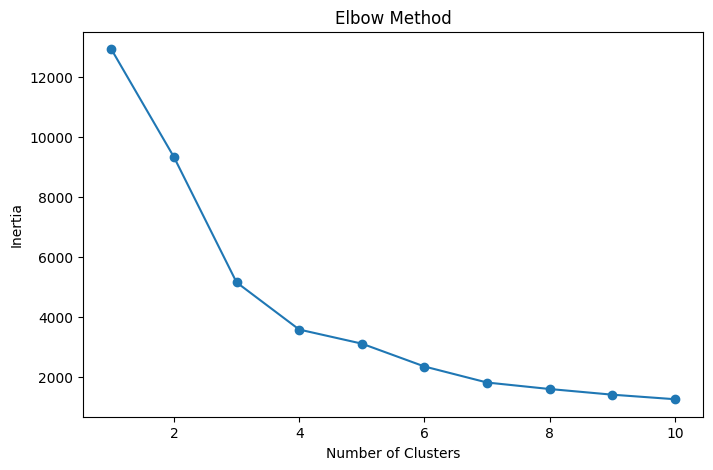

In [118]:
# Visualize elbow curve
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

Selected K = 4 based on elbow point.

In [119]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm_df["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

In [120]:
rfm_df["Cluster"].value_counts()

Cluster
0    3204
1    1047
3      56
2       5
Name: count, dtype: int64

In [121]:
# Average RFM values per cluster
cluster_summary = rfm_df.groupby(
    "Cluster"
)[
    ["Recency", "Frequency", "Monetary"]
].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.031835,4.455056,1710.650030
1,242.976122,1.659981,593.540319
2,5.600000,113.600000,215535.000000
3,14.910714,47.017857,28896.416661


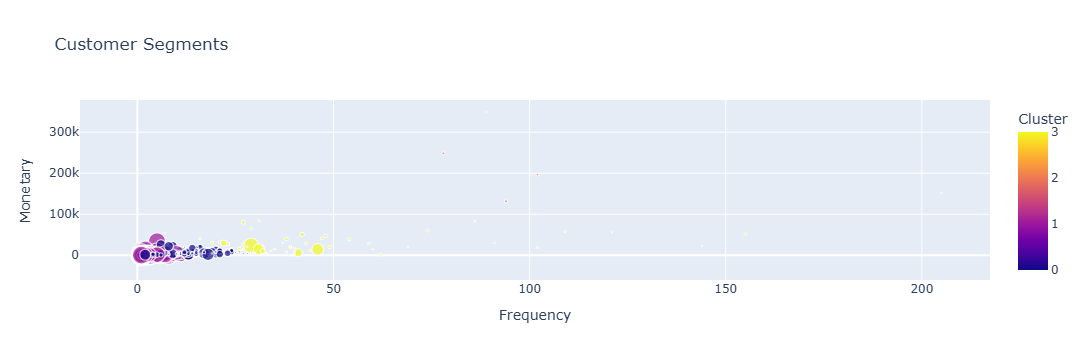

In [122]:
# Customer segmentation plot
fig = px.scatter(
    rfm_df,
    x="Frequency",
    y="Monetary",
    color="Cluster",
    size="Recency",
    hover_data=["CustomerID"],
    title="Customer Segments"
)

fig.show()

In [123]:
rfm_df.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\neuralretail\data\processed\customer_segments.csv",
    index=False
)

In [124]:
segment_map = {

    0: "Regular Customers",

    1: "At Risk Customers",

    2: "Ultra VIP Customers",

    3: "Loyal High-Value Customers"
}

In [125]:
rfm_df["Segment"] = rfm_df[
    "Cluster"
].map(segment_map)

In [126]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(
    rfm_scaled,
    rfm_df["Cluster"]
)

print(
    "KMeans Silhouette:",
    round(kmeans_score, 4)
)

KMeans Silhouette: 0.6108


In [127]:
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,165,11,372.86,1,At Risk Customers
1,12347,3,2,1323.32,0,Regular Customers
2,12348,74,1,222.16,0,Regular Customers
3,12349,43,3,2671.14,0,Regular Customers
4,12351,11,1,300.93,0,Regular Customers


In [128]:
rfm_df.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\neuralretail\data\processed\customer_segments_labeled.csv",
    index=False
)

DBSCAN

In [136]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.7,
    min_samples=20
)

rfm_df["DBSCAN_Cluster"] = dbscan.fit_predict(
    rfm_scaled
)

print(
    rfm_df["DBSCAN_Cluster"]
    .value_counts()
)

DBSCAN_Cluster
 0    4245
-1      67
Name: count, dtype: int64


In [137]:
dbscan_summary = rfm_df.groupby(
    "DBSCAN_Cluster"
)[
    ["Recency", "Frequency", "Monetary"]
].mean()

print(dbscan_summary)

                  Recency  Frequency      Monetary
DBSCAN_Cluster                                    
-1              26.417910  48.104478  42203.544672
 0              92.193875   3.766784   1406.500884


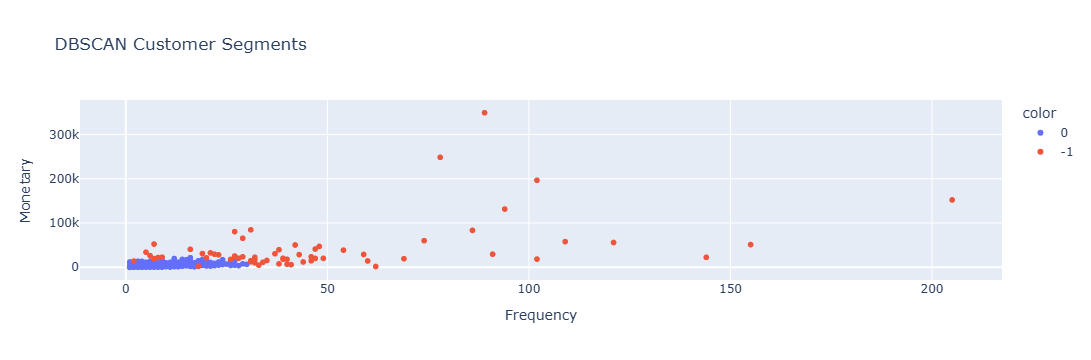

In [138]:
fig = px.scatter(

    rfm_df,

    x="Frequency",

    y="Monetary",

    color=rfm_df["DBSCAN_Cluster"].astype(str),

    title="DBSCAN Customer Segments"
)

fig.show()

In [139]:
valid = rfm_df["DBSCAN_Cluster"] != -1

if len(
    rfm_df.loc[valid, "DBSCAN_Cluster"]
    .unique()
) > 1:

    dbscan_score = silhouette_score(
        rfm_scaled[valid],
        rfm_df.loc[valid, "DBSCAN_Cluster"]
    )

    print(
        "DBSCAN Silhouette:",
        round(dbscan_score, 4)
    )

In [148]:
rfm_df.to_csv(

    r"C:\Users\91991\Desktop\internships\AMDOX\neuralretail\data\processed\customer_segments_dbscan.csv",

    index=False
)

gmm

In [149]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

rfm_df["GMM_Cluster"] = gmm.fit_predict(
    rfm_scaled
)

print(
    rfm_df["GMM_Cluster"]
    .value_counts()
)

GMM_Cluster
1    2108
0    1573
3     564
2      67
Name: count, dtype: int64


In [150]:
gmm_summary = rfm_df.groupby(
    "GMM_Cluster"
)[
    ["Recency", "Frequency", "Monetary"]
].mean()

print(gmm_summary)

                Recency  Frequency      Monetary
GMM_Cluster                                     
0             32.809917   4.912905   1623.660461
1            138.541746   1.439279    350.152676
2              5.119403  48.462687  41156.923910
3             87.117021   9.226950   4873.368963


In [151]:
gmm_labels = {

    0: "Loyal Customers",

    1: "At-Risk Customers",

    2: "VIP Customers",

    3: "High-Value Customers"
}

rfm_df["Segment"] = (
    rfm_df["GMM_Cluster"]
    .map(gmm_labels)
)

In [152]:
rfm_df.to_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\neuralretail\data\processed\customer_segments_labeled.csv",
    index=False
)


In [153]:
print(rfm_df.columns.tolist())

['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment', 'GMM_Cluster', 'DBSCAN_Cluster']


In [154]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(
    rfm_scaled,
    rfm_df["Cluster"]
)

gmm_score = silhouette_score(
    rfm_scaled,
    rfm_df["GMM_Cluster"]
)
DBSCAN_score  = silhouette_score(
    rfm_scaled,
    rfm_df["DBSCAN_Cluster"]
)

print("KMeans:", kmeans_score)
print("GMM:", gmm_score)
print("DBSCAN:", DBSCAN_score)

KMeans: 0.6107948209557895
GMM: 0.14526560272222253
DBSCAN: 0.8215197215487599
